# Dist 3 Analysis (Filtered)

This notebook analyzes the participant data in `Experiment1/data/dist 3/data`.
For conditions `18`, `19`, and `20`, it keeps only participants who answered `Yes` to either `encounter_bug` or `annoying_design` on the phase 2 feedback page; conditions `4`, `5`, and `6` are not additionally filtered.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", None)

## 1. Data Loading and Preprocessing

In [2]:
DATA_DIR = Path("./data/dist 3/data")
CSV_PATTERN = "user_*.csv"

FILTERED_CONDITIONS = {18, 19, 20}
UNFILTERED_CONDITIONS = {4, 5, 6}
FOCUS_CONDITIONS = FILTERED_CONDITIONS | UNFILTERED_CONDITIONS


def extract_condition_number(condition_id):
    if pd.isna(condition_id):
        return np.nan

    for part in str(condition_id).split("_"):
        if part.isdigit():
            return int(part)

    return np.nan


def load_participant_data(file_path):
    df = pd.read_csv(file_path)
    df["source_file"] = file_path.name

    if "participant_id" not in df.columns or df["participant_id"].isna().all():
        participant_id = file_path.stem.split("_")[1]
        df["participant_id"] = participant_id

    if "condition_id" in df.columns:
        df["condition_id"] = df["condition_id"].fillna("unknown")
        df["condition_number"] = df["condition_id"].apply(extract_condition_number)
    else:
        df["condition_id"] = "unknown"
        df["condition_number"] = np.nan

    return df


def parse_filter_response(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        return json.loads(value)
    except Exception:
        return {}


def normalize_yes_no(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in {"yes", "y", "true", "1"}:
        return "Yes"
    if text in {"no", "n", "false", "0"}:
        return "No"
    return np.nan


def summarize_condition_participants(data, conditions):
    return (
        data.loc[data["condition_number"].isin(sorted(conditions)), ["participant_id", "condition_number"]]
        .drop_duplicates()
        .groupby("condition_number")["participant_id"]
        .nunique()
        .reindex(sorted(conditions), fill_value=0)
    )


def build_feedback_filter_table(data):
    feedback_rows = data[
        (data["trial_type"] == "interaction-feedback")
        & (data["phase"] == 2)
        & data["condition_number"].isin(FILTERED_CONDITIONS)
    ].copy()

    parsed_feedback = feedback_rows["response"].apply(parse_filter_response).apply(pd.Series)
    feedback_rows = pd.concat(
        [feedback_rows.reset_index(drop=True), parsed_feedback.reset_index(drop=True)],
        axis=1,
    )

    for col in ["encounter_bug", "annoying_design"]:
        if col not in feedback_rows.columns:
            feedback_rows[col] = np.nan
        feedback_rows[col] = feedback_rows[col].apply(normalize_yes_no)

    feedback_rows["keep_participant"] = (
        feedback_rows["encounter_bug"].eq("Yes")
        | feedback_rows["annoying_design"].eq("Yes")
    )

    return feedback_rows[
        [
            "participant_id",
            "condition_number",
            "condition_name",
            "encounter_bug",
            "annoying_design",
            "keep_participant",
        ]
    ].drop_duplicates().sort_values(["condition_number", "participant_id"]).reset_index(drop=True)


csv_files = sorted(DATA_DIR.glob(CSV_PATTERN))
print(f"Using data directory: {DATA_DIR.resolve()}")
print(f"Found {len(csv_files)} participant CSV files")
print("Sample files:")
for file_path in csv_files[:10]:
    print(f"  - {file_path.name}")
if len(csv_files) > 10:
    print(f"  ... and {len(csv_files) - 10} more")

all_data = [load_participant_data(file_path) for file_path in csv_files]
combined_data = pd.concat(all_data, ignore_index=True)

before_participants = combined_data["participant_id"].nunique(dropna=True)
combined_data = combined_data[combined_data["participant_id"].notna()].copy()
combined_data = combined_data[~combined_data["participant_id"].astype(str).str.lower().eq("test")].copy()
participants_after_basic_cleanup = combined_data["participant_id"].nunique(dropna=True)

participant_counts_before_filter = summarize_condition_participants(combined_data, FOCUS_CONDITIONS)
feedback_filter_table = build_feedback_filter_table(combined_data)
participants_in_filtered_conditions = set(
    combined_data.loc[
        combined_data["condition_number"].isin(FILTERED_CONDITIONS), "participant_id"
    ].dropna()
)
participants_passing_filter = set(
    feedback_filter_table.loc[feedback_filter_table["keep_participant"], "participant_id"]
)
participants_removed_by_filter = participants_in_filtered_conditions - participants_passing_filter
combined_data = combined_data[~combined_data["participant_id"].isin(participants_removed_by_filter)].copy()

after_participants = combined_data["participant_id"].nunique(dropna=True)
participant_counts_after_filter = summarize_condition_participants(combined_data, FOCUS_CONDITIONS)
participant_filter_summary = pd.DataFrame(
    {
        "before": participant_counts_before_filter,
        "after": participant_counts_after_filter,
    }
).fillna(0).astype(int)
participant_filter_summary.index = participant_filter_summary.index.astype(int)
participant_filter_summary = participant_filter_summary.reset_index().rename(
    columns={"index": "condition_number"}
)

print()
print("Condition-specific filter applied:")
print("  Conditions 18, 19, 20: kept only participants who answered Yes to Bug or bad design on the feedback page.")
print("  Conditions 4, 5, 6: no additional participant filter.")
print(f"  Removed participants from conditions 18/19/20: {len(participants_removed_by_filter)}")
display(participant_filter_summary)

print()
print(f"Combined dataset shape: {combined_data.shape}")
print(f"Participants after cleanup: {before_participants} -> {participants_after_basic_cleanup}")
print(f"Participants after condition-specific filter: {participants_after_basic_cleanup} -> {after_participants}")

Using data directory: /Users/songwen/Documents/Code Lab/Interact4Trust/Experiment1/data/dist 3/data
Found 104 participant CSV files
Sample files:
  - user_5015806700019318_2026-03-01T18-22-49-132.csv
  - user_50757123719421_2026-03-01T18-25-52-980.csv
  - user_50768174490167699_2026-03-01T18-23-55-407.csv
  - user_507846166510_2026-03-01T18-10-25-544.csv
  - user_512801430018385_2026-03-01T18-33-28-144.csv
  - user_5151118148000161086_2026-03-01T18-13-24-532.csv
  - user_516959870014161_2026-03-01T18-14-29-602.csv
  - user_5308729263285729_2026-03-01T18-14-43-337.csv
  - user_530941067700010_2026-03-01T18-21-43-587.csv
  - user_5316175500018596_2026-03-01T18-17-25-554.csv
  ... and 94 more

Condition-specific filter applied:
  Conditions 18, 19, 20: kept only participants who answered Yes to Bug or bad design on the feedback page.
  Conditions 4, 5, 6: no additional participant filter.
  Removed participants from conditions 18/19/20: 40


,condition_number,before,after
0,4,19,19
1,5,17,17
2,6,16,16
3,18,19,5
4,19,15,4
5,20,18,3



Combined dataset shape: (1472, 61)
Participants after cleanup: 104 -> 104
Participants after condition-specific filter: 104 -> 64


In [3]:
print("Column names:")
print(combined_data.columns.tolist())

print("\nTrial type counts:")
print(combined_data["trial_type"].value_counts(dropna=False).to_string())

condition_lookup = (
    combined_data.loc[combined_data["condition_number"].notna(), ["condition_number", "condition_name", "condition_id"]]
    .drop_duplicates()
    .sort_values("condition_number")
    .reset_index(drop=True)
)

print("\nConditions present in this dataset:")
display(condition_lookup)

Column names:
['city_a_estimate', 'city_b_estimate', 'click_events', 'comprehension_ease', 'condition', 'condition_id', 'condition_name', 'confidence_label', 'confidence_rating', 'data_trust', 'device_pixel_ratio', 'display_format', 'effective_screen_width_px', 'end_time', 'failed_audio', 'failed_images', 'failed_video', 'hover_events', 'interaction_log', 'internal_node_id', 'participant_id', 'percent_score', 'phase', 'phase1_complete', 'phase2_complete', 'predictions_shown', 'probability_estimate', 'question_order', 'response', 'responses', 'round', 'rt', 'rt_total', 'screen_height', 'screen_width', 'skeptical_rating', 'slider_moved', 'start_time', 'stimulus', 'success', 'time_elapsed', 'time_on_viz', 'timeout', 'total_interactions', 'total_questions', 'total_score', 'travel_choice', 'trial_index', 'trial_type', 'trust_composite', 'ui_scale_preset', 'usability_composite', 'usability_difficulty', 'view_history', 'visualization_interaction_requirement_bypass_reason', 'visualization_inte

,condition_number,condition_name,condition_id
0,0.0,Historical Only,condition_0_historical
1,4.0,Ensemble + Hover,condition_4_ensemble_hover
2,5.0,PI Plot + Hover,condition_5_pi_hover
3,6.0,PI → Ensemble,condition_6_pi_to_ensemble
4,18.0,Glitch Ensemble + Hover,condition_18_glitch_hover
5,19.0,Glitch PI Plot + Hover,condition_19_glitch_pi_hover
6,20.0,Glitch PI → Ensemble,condition_20_glitch_pi_to_ensemble


In [4]:
relevant_trial_types = [
    "prediction-task",
    "vis-literacy",
    "trust-survey",
    "personality-survey",
    "survey-text",
    "survey-multi-choice",
]

relevant_trials = combined_data[combined_data["trial_type"].isin(relevant_trial_types)].copy()
relevant_trials["interaction_freq"] = np.log1p(
    relevant_trials["interaction_log"].fillna("").astype(str).str.len()
)

prediction_data = relevant_trials[relevant_trials["trial_type"] == "prediction-task"].copy()
phase1_data = prediction_data[prediction_data["phase"] == 1].copy()
phase2_data = prediction_data[prediction_data["phase"] == 2].copy()

treatment_conditions = sorted(
    int(value)
    for value in phase2_data["condition_number"].dropna().unique()
    if int(value) != 0
)

print(f"Relevant trial rows: {len(relevant_trials)}")
print(f"Prediction rows: {len(prediction_data)}")
print(f"Phase 1 rows: {len(phase1_data)}")
print(f"Phase 2 rows: {len(phase2_data)}")
print(f"Treatment conditions: {treatment_conditions}")

Relevant trial rows: 576
Prediction rows: 128
Phase 1 rows: 64
Phase 2 rows: 64
Treatment conditions: [4, 5, 6, 18, 19, 20]


## 2. Basic Statistics Tables by Condition

In [5]:
def create_condition_response_table(data, response_columns):
    rows = []

    grouped = data.groupby(["condition_number", "condition_name"], dropna=False)
    for (condition_number, condition_name), group in grouped:
        row_label = f"{int(condition_number)} - {condition_name}" if pd.notna(condition_number) else str(condition_name)
        row = {"condition": row_label, "participants": group["participant_id"].nunique()}
        for col in response_columns:
            row[col] = group[col].dropna().tolist() if col in group.columns else []
        rows.append(row)

    return pd.DataFrame(rows).set_index("condition")


def summarize_prediction_metrics(data, response_columns):
    summary = (
        data.groupby(["condition_number", "condition_name"], dropna=False)
        .agg(
            participants=("participant_id", "nunique"),
            probability_mean=("probability_estimate", "mean"),
            probability_sd=("probability_estimate", "std"),
            confidence_mean=("confidence_rating", "mean"),
            confidence_sd=("confidence_rating", "std"),
            interaction_mean=("interaction_freq", "mean"),
            interaction_sd=("interaction_freq", "std"),
        )
        .round(2)
        .reset_index()
        .sort_values("condition_number")
    )

    available_columns = [col for col in response_columns if col in data.columns]
    count_summary = (
        data.groupby(["condition_number", "condition_name"], dropna=False)[available_columns]
        .count()
        .reset_index()
        .sort_values("condition_number")
    )

    return summary, count_summary


phase1_columns = ["probability_estimate", "confidence_rating", "travel_choice"]
phase2_columns = [
    "probability_estimate",
    "confidence_rating",
    "travel_choice",
    "data_trust",
    "skeptical_rating",
]

phase1_response_table = create_condition_response_table(phase1_data, phase1_columns)
phase2_response_table = create_condition_response_table(phase2_data, phase2_columns)
phase1_summary, phase1_counts = summarize_prediction_metrics(phase1_data, phase1_columns)
phase2_summary, phase2_counts = summarize_prediction_metrics(phase2_data, phase2_columns)

print("Phase 1 response lists")
display(phase1_response_table)
print("Phase 1 summary")
display(phase1_summary)
print("Phase 1 non-null counts")
display(phase1_counts)

print("Phase 2 response lists")
display(phase2_response_table)
print("Phase 2 summary")
display(phase2_summary)
print("Phase 2 non-null counts")
display(phase2_counts)

Phase 1 response lists


,participants,probability_estimate,confidence_rating,travel_choice
condition,,,,
0 - Historical Only,64,"[10.0, 18.0, 66.0, 14.0, 10.0, 26.0, 60.0, 68....","[5.0, 4.0, 2.0, 5.0, 5.0, 5.0, 4.0, 3.0, 5.0, ...","[City A, City A, City A, No Preference, City A..."


Phase 1 summary


,condition_number,condition_name,participants,probability_mean,probability_sd,confidence_mean,confidence_sd,interaction_mean,interaction_sd
0,0.0,Historical Only,64,21.8,21.36,4.39,1.43,9.64,3.77


Phase 1 non-null counts


...

,participants,probability_estimate,confidence_rating,travel_choice,data_trust,skeptical_rating
condition,,,,,,
4 - Ensemble + Hover,19,"[10.0, 4.0, 10.0, 7.0, 14.0, 25.0, 20.0, 10.0,...","[4.0, 6.0, 5.0, 6.0, 5.0, 5.0, 4.0, 5.0, 5.0, ...","[City A, City A, City A, City A, City A, City ...",[],[]
5 - PI Plot + Hover,17,"[28.0, 18.0, 0.0, 2.0, 30.0, 60.0, 8.0, 9.0, 1...","[5.0, 4.0, 6.0, 4.0, 6.0, 2.0, 5.0, 5.0, 1.0, ...","[City A, City A, City A, City A, City A, No Pr...",[],[]
6 - PI → Ensemble,16,"[5.0, 6.0, 50.0, 0.0, 4.0, 8.0, 100.0, 17.0, 7...","[5.0, 3.0, 4.0, 5.0, 5.0, 4.0, 6.0, 6.0, 5.0, ...","[City A, City A, City A, City A, City A, City ...",[],[]
18 - Glitch Ensemble + Hover,5,"[75.0, 30.0, 15.0, 9.0, 18.0]","[4.0, 2.0, 5.0, 6.0, 6.0]","[No Preference, City A, City A, City A, City A]",[],[]
19 - Glitch PI Plot + Hover,4,"[30.0, 90.0, 0.0, 0.0]","[5.0, 2.0, 7.0, 6.0]","[City A, City A, City A, City A]",[],[]
20 - Glitch PI → Ensemble,3,"[80.0, 2.0, 0.0]","[1.0, 6.0, 5.0]","[No Preference, City A, City A]",[],[]


Phase 2 summary


,condition_number,condition_name,participants,probability_mean,probability_sd,confidence_mean,confidence_sd,interaction_mean,interaction_sd
0,4.0,Ensemble + Hover,19,18.37,20.45,5.37,0.83,11.53,1.57
1,5.0,PI Plot + Hover,17,18.06,17.20,4.71,1.40,11.55,1.68
2,6.0,PI → Ensemble,16,26.62,30.66,4.75,1.06,11.99,1.17
3,18.0,Glitch Ensemble + Hover,5,29.40,26.61,4.60,1.67,11.79,0.76
4,19.0,Glitch PI Plot + Hover,4,30.00,42.43,5.00,2.16,12.22,0.34
5,20.0,Glitch PI → Ensemble,3,27.33,45.62,4.00,2.65,12.76,0.59


Phase 2 non-null counts


,condition_number,condition_name,probability_estimate,confidence_rating,travel_choice,data_trust,skeptical_rating
0,4.0,Ensemble + Hover,19,19,19,0,0
1,5.0,PI Plot + Hover,17,17,17,0,0
2,6.0,PI → Ensemble,16,16,16,0,0
3,18.0,Glitch Ensemble + Hover,5,5,5,0,0
4,19.0,Glitch PI Plot + Hover,4,4,4,0,0
5,20.0,Glitch PI → Ensemble,3,3,3,0,0


## 3. Phase 1 to Phase 2 Shift Visualizations

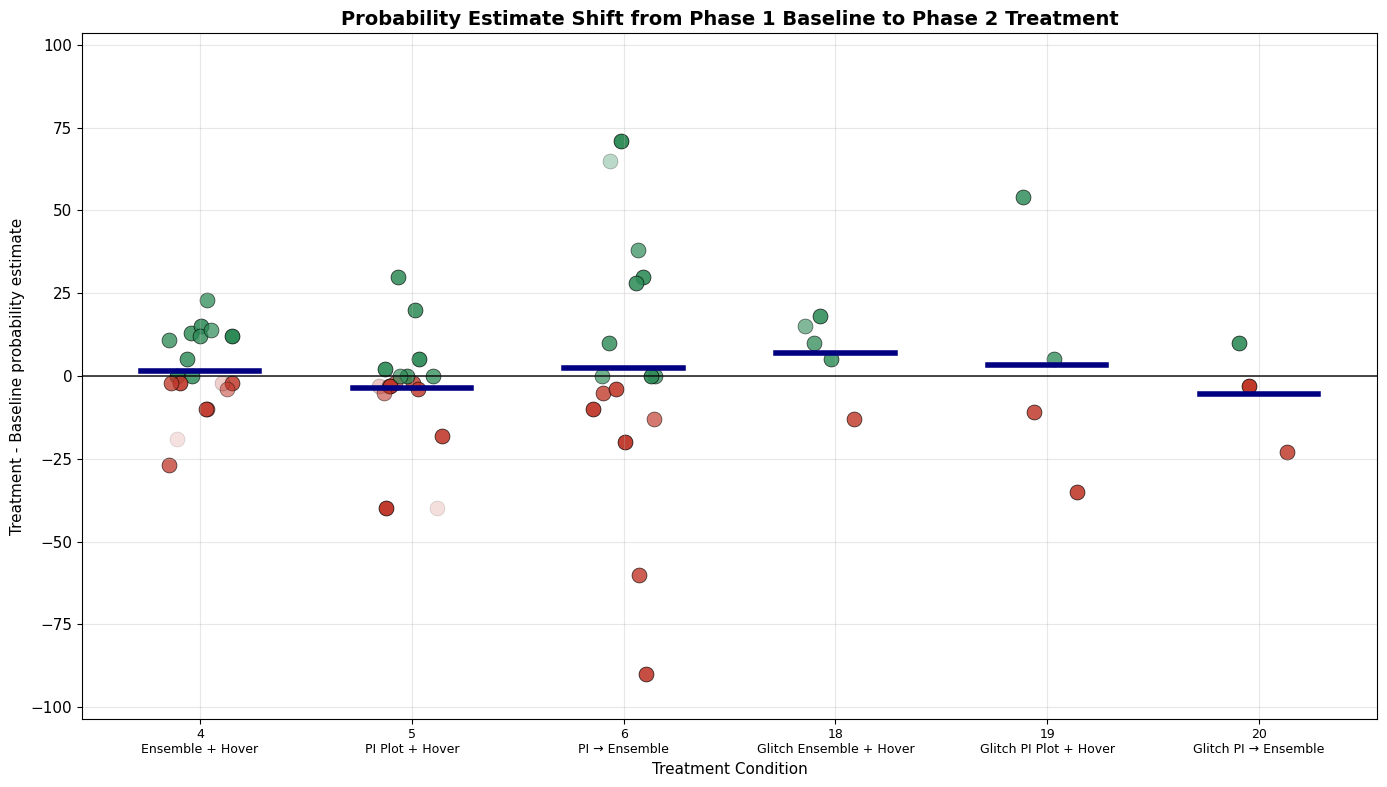

Shift summary for probability_estimate


,condition_number,condition_name,n,mean_shift,sd_shift,mean_interaction
0,4.0,Ensemble + Hover,19,1.42,12.55,11.53
1,5.0,PI Plot + Hover,17,-3.71,17.13,11.55
2,6.0,PI → Ensemble,16,2.50,40.66,11.99
3,18.0,Glitch Ensemble + Hover,5,7.00,12.23,11.79
4,19.0,Glitch PI Plot + Hover,4,3.25,37.62,12.22
5,20.0,Glitch PI → Ensemble,3,-5.33,16.62,12.76


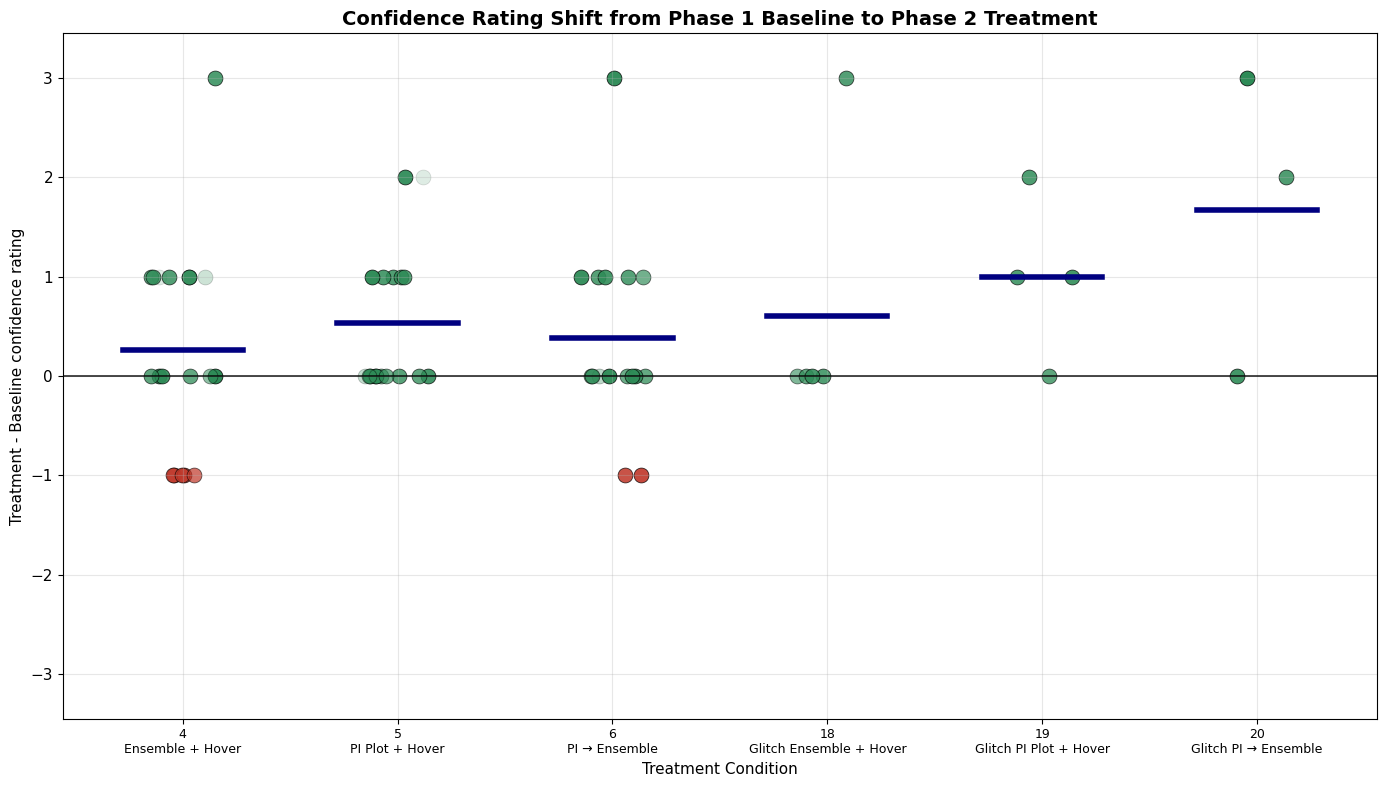

Shift summary for confidence_rating


,condition_number,condition_name,n,mean_shift,sd_shift,mean_interaction
0,4.0,Ensemble + Hover,19,0.26,1.05,11.53
1,5.0,PI Plot + Hover,17,0.53,0.72,11.55
2,6.0,PI → Ensemble,16,0.38,0.96,11.99
3,18.0,Glitch Ensemble + Hover,5,0.60,1.34,11.79
4,19.0,Glitch PI Plot + Hover,4,1.00,0.82,12.22
5,20.0,Glitch PI → Ensemble,3,1.67,1.53,12.76


In [6]:
def create_shift_plot(phase1_data, phase2_data, value_col, title, y_label, y_limits=None):
    baseline = (
        phase1_data.loc[phase1_data[value_col].notna(), ["participant_id", value_col]]
        .drop_duplicates(subset=["participant_id"], keep="last")
        .rename(columns={value_col: f"{value_col}_baseline"})
    )

    treatment = phase2_data[
        phase2_data["condition_number"].notna() & phase2_data[value_col].notna()
    ].copy()
    treatment = treatment[treatment["condition_number"] != 0].copy()

    merged = treatment.merge(baseline, on="participant_id", how="inner")
    if merged.empty:
        print(f"No matched baseline/treatment rows found for {value_col}")
        return None

    merged["shift"] = merged[value_col] - merged[f"{value_col}_baseline"]
    merged["interaction_freq"] = merged["interaction_freq"].fillna(0)

    if merged["interaction_freq"].nunique() > 1:
        freq_min = merged["interaction_freq"].min()
        freq_max = merged["interaction_freq"].max()
        merged["opacity"] = 0.15 + (merged["interaction_freq"] - freq_min) / (freq_max - freq_min) * 0.85
    else:
        merged["opacity"] = 0.75

    summary = (
        merged.groupby(["condition_number", "condition_name"])
        .agg(
            n=("participant_id", "size"),
            mean_shift=("shift", "mean"),
            sd_shift=("shift", "std"),
            mean_interaction=("interaction_freq", "mean"),
        )
        .round(2)
        .reset_index()
        .sort_values("condition_number")
    )

    position_map = {
        int(condition_number): index + 1
        for index, condition_number in enumerate(summary["condition_number"].astype(int).tolist())
    }

    plot_data = merged.copy()
    plot_data["x_position"] = plot_data["condition_number"].astype(int).map(position_map)

    np.random.seed(42)
    jitter = np.random.uniform(-0.16, 0.16, len(plot_data))
    colors = np.where(plot_data["shift"] >= 0, "#2E8B57", "#C0392B")

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axhline(0, color="black", linewidth=1.25, alpha=0.8)

    for x_pos, shift, alpha, color in zip(plot_data["x_position"] + jitter, plot_data["shift"], plot_data["opacity"], colors):
        ax.scatter(x_pos, shift, s=115, alpha=alpha, color=color, edgecolors="black", linewidth=0.5)

    for _, row in summary.iterrows():
        x_pos = position_map[int(row["condition_number"])]
        ax.plot([x_pos - 0.28, x_pos + 0.28], [row["mean_shift"], row["mean_shift"]], color="navy", linewidth=4)

    labels = [
        f"{int(row.condition_number)}\n{row.condition_name}"
        for row in summary.itertuples(index=False)
    ]
    ax.set_xticks(list(position_map.values()))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel("Treatment Condition")
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)

    if y_limits is not None:
        ax.set_ylim(*y_limits)
    else:
        max_abs_shift = max(abs(plot_data["shift"].min()), abs(plot_data["shift"].max()))
        padded_limit = max_abs_shift * 1.15 if max_abs_shift else 1
        ax.set_ylim(-padded_limit, padded_limit)

    plt.tight_layout()
    plt.show()

    print(f"Shift summary for {value_col}")
    display(summary)
    return plot_data, summary


probability_shift_data, probability_shift_summary = create_shift_plot(
    phase1_data,
    phase2_data,
    value_col="probability_estimate",
    title="Probability Estimate Shift from Phase 1 Baseline to Phase 2 Treatment",
    y_label="Treatment - Baseline probability estimate",
)

confidence_shift_data, confidence_shift_summary = create_shift_plot(
    phase1_data,
    phase2_data,
    value_col="confidence_rating",
    title="Confidence Rating Shift from Phase 1 Baseline to Phase 2 Treatment",
    y_label="Treatment - Baseline confidence rating",
)

## 4. Trust and Usability Measures

In [7]:
INTERACTION_QUESTION_KEYS = [
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_exploration",
    "interface_responsiveness",
    "user_communication",
    "personal_conversation",
    "interface_interaction",
    "interface_sensitivity",
]

TRUST_QUESTION_KEYS = [
    "skeptical_rating",
    "data_trust",
    "usability_difficulty",
    "comprehension_ease",
]

DEMOGRAPHIC_QUESTION_KEYS = [
    "respect_others",
    "good_word_everyone",
    "retreat_from_others",
    "avoid_contacts",
]


def parse_response_json(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        return json.loads(value)
    except Exception:
        return {}


def expand_response_columns(data):
    parsed = data["response"].apply(parse_response_json)
    expanded = pd.json_normalize(parsed)
    expanded = expanded.apply(lambda col: pd.to_numeric(col, errors="ignore"))
    base = data.reset_index(drop=True).copy()
    overlap = [col for col in expanded.columns if col in base.columns]
    if overlap:
        base = base.drop(columns=overlap)
    return pd.concat([base, expanded], axis=1)


trust_survey_rows = relevant_trials[relevant_trials["trial_type"] == "trust-survey"].copy()
trust_survey_expanded = expand_response_columns(trust_survey_rows)
interaction_data = trust_survey_expanded[trust_survey_expanded["navigation_control"].notna()].copy()
trust_data = trust_survey_expanded[trust_survey_expanded["skeptical_rating"].notna()].copy()

personality_data = expand_response_columns(
    relevant_trials[relevant_trials["trial_type"] == "personality-survey"].copy()
)
multi_choice_data = expand_response_columns(
    relevant_trials[relevant_trials["trial_type"] == "survey-multi-choice"].copy()
)
survey_text_data = expand_response_columns(
    relevant_trials[relevant_trials["trial_type"] == "survey-text"].copy()
)

for col in INTERACTION_QUESTION_KEYS + TRUST_QUESTION_KEYS + DEMOGRAPHIC_QUESTION_KEYS:
    for dataset in [interaction_data, trust_data, personality_data]:
        if col in dataset.columns:
            dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

print("Expanded survey datasets")
print(f"  Interaction survey rows: {len(interaction_data)}")
print(f"  Trust survey rows: {len(trust_data)}")
print(f"  Personality survey rows: {len(personality_data)}")
print(f"  Multi-choice rows: {len(multi_choice_data)}")
print(f"  Survey-text rows: {len(survey_text_data)}")

Expanded survey datasets
  Interaction survey rows: 64
  Trust survey rows: 64
  Personality survey rows: 64
  Multi-choice rows: 64
  Survey-text rows: 128


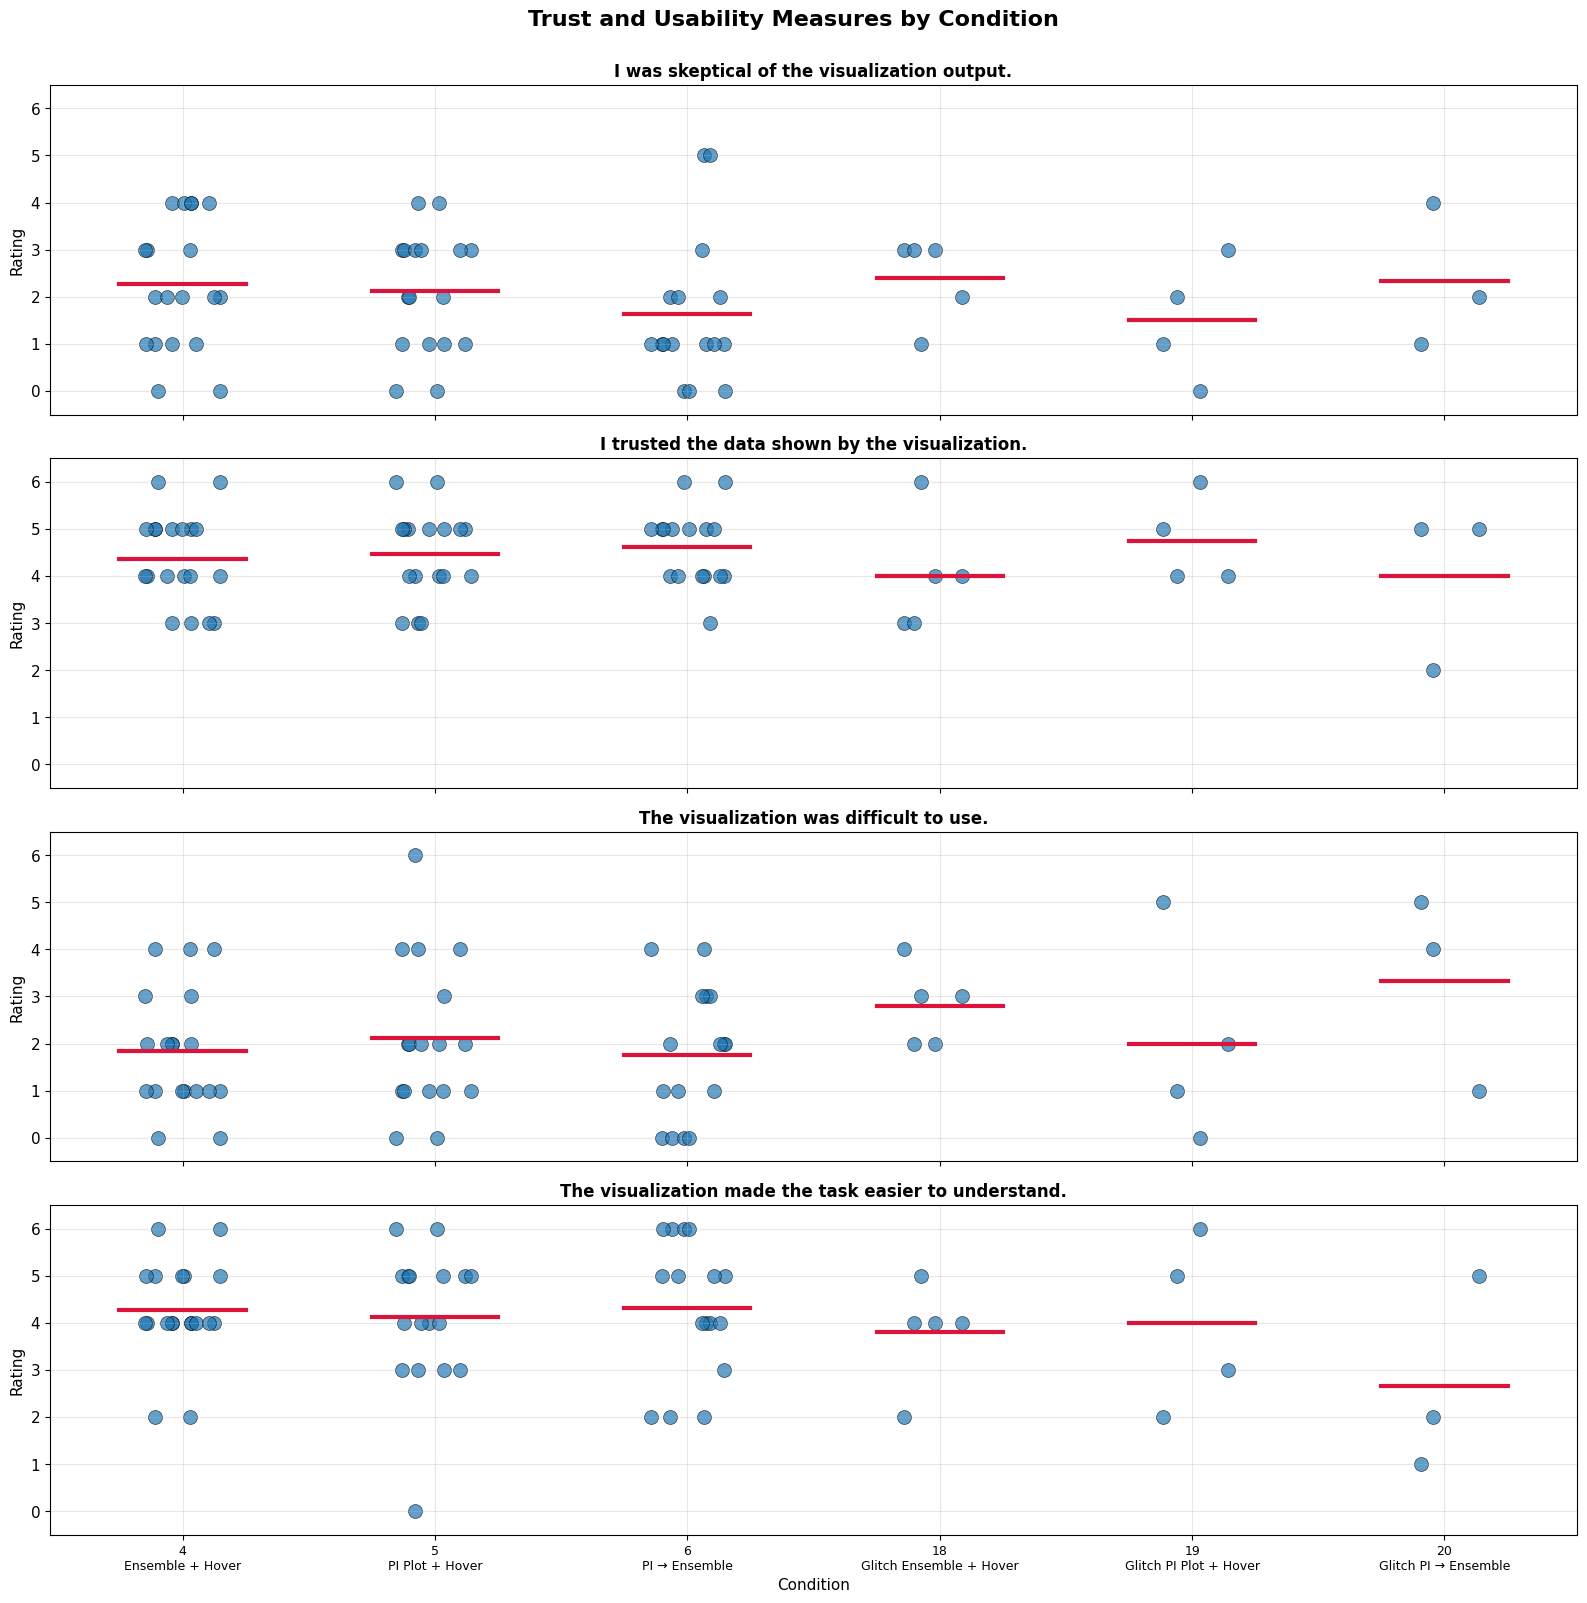

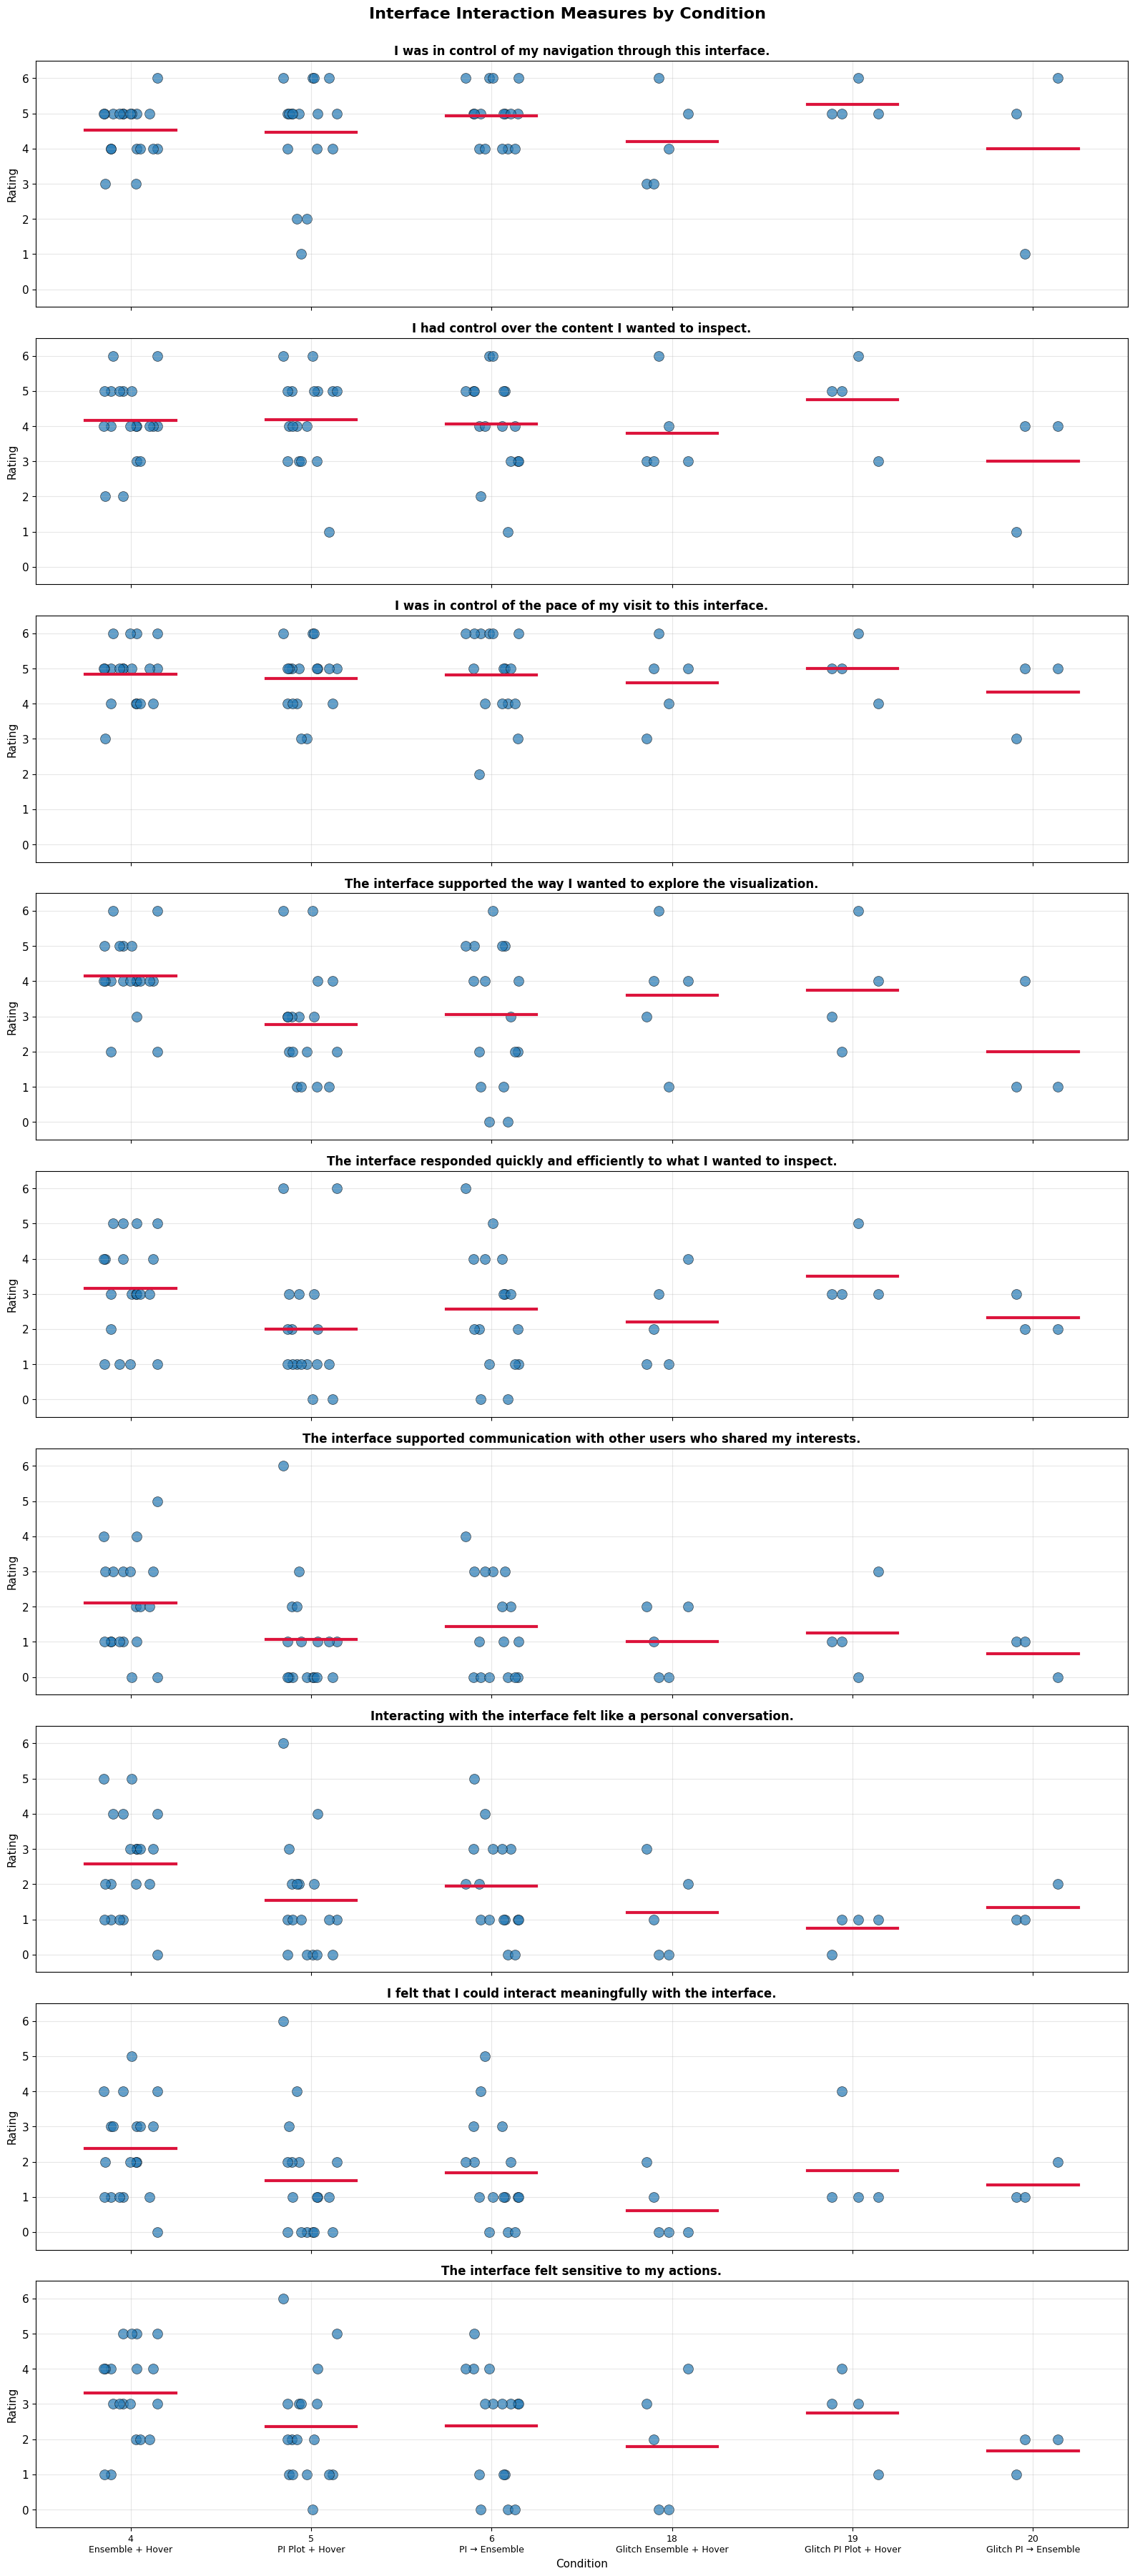

In [8]:
interaction_questions = [
    {"type": "navigation_control", "prompt": "I was in control of my navigation through this interface."},
    {"type": "content_control", "prompt": "I had control over the content I wanted to inspect."},
    {"type": "pace_control", "prompt": "I was in control of the pace of my visit to this interface."},
    {"type": "interface_exploration", "prompt": "The interface supported the way I wanted to explore the visualization."},
    {"type": "interface_responsiveness", "prompt": "The interface responded quickly and efficiently to what I wanted to inspect."},
    {"type": "user_communication", "prompt": "The interface supported communication with other users who shared my interests."},
    {"type": "personal_conversation", "prompt": "Interacting with the interface felt like a personal conversation."},
    {"type": "interface_interaction", "prompt": "I felt that I could interact meaningfully with the interface."},
    {"type": "interface_sensitivity", "prompt": "The interface felt sensitive to my actions."},
]

trust_questions = [
    {"type": "skeptical_rating", "prompt": "I was skeptical of the visualization output."},
    {"type": "data_trust", "prompt": "I trusted the data shown by the visualization."},
    {"type": "usability_difficulty", "prompt": "The visualization was difficult to use."},
    {"type": "comprehension_ease", "prompt": "The visualization made the task easier to understand."},
]


def create_sectioned_survey_plots(data, questions, section_title, exclude_baseline=True):
    if data.empty:
        print(f"No data available for {section_title}")
        return

    condition_frame = (
        data[["condition_number", "condition_name"]]
        .dropna()
        .drop_duplicates()
        .sort_values("condition_number")
    )
    if exclude_baseline:
        condition_frame = condition_frame[condition_frame["condition_number"] != 0]

    position_map = {
        int(row.condition_number): index + 1
        for index, row in enumerate(condition_frame.itertuples(index=False))
    }
    labels = [
        f"{int(row.condition_number)}\n{row.condition_name}"
        for row in condition_frame.itertuples(index=False)
    ]

    fig, axes = plt.subplots(len(questions), 1, figsize=(16, 4 * len(questions)), sharex=True)
    if len(questions) == 1:
        axes = [axes]

    for ax, question in zip(axes, questions):
        key = question["type"]
        plot_rows = data[data[key].notna() & data["condition_number"].notna()].copy()
        if exclude_baseline:
            plot_rows = plot_rows[plot_rows["condition_number"] != 0].copy()

        if plot_rows.empty:
            ax.set_title(question["prompt"], fontsize=12, fontweight="bold")
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
            continue

        plot_rows["x_position"] = plot_rows["condition_number"].astype(int).map(position_map)
        np.random.seed(42)
        jitter = np.random.uniform(-0.16, 0.16, len(plot_rows))
        ax.scatter(
            plot_rows["x_position"] + jitter,
            plot_rows[key],
            alpha=0.7,
            s=100,
            edgecolors="black",
            linewidth=0.5,
            color="#1f77b4",
        )

        means = plot_rows.groupby("condition_number")[key].mean()
        for condition_number, mean_value in means.items():
            x_pos = position_map[int(condition_number)]
            ax.plot([x_pos - 0.25, x_pos + 0.25], [mean_value, mean_value], color="crimson", linewidth=3)

        ax.set_title(question["prompt"], fontsize=12, fontweight="bold")
        ax.set_ylabel("Rating")
        ax.set_ylim(-0.5, 6.5)
        ax.grid(True, axis="y", alpha=0.3)

    axes[-1].set_xticks(list(position_map.values()))
    axes[-1].set_xticklabels(labels, fontsize=9)
    axes[-1].set_xlabel("Condition")
    fig.suptitle(section_title, fontsize=16, fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.show()


create_sectioned_survey_plots(
    trust_data,
    trust_questions,
    section_title="Trust and Usability Measures by Condition",
)

create_sectioned_survey_plots(
    interaction_data,
    interaction_questions,
    section_title="Interface Interaction Measures by Condition",
)

## 5. Composite Scores, Interaction Frequency, and Feedback Page

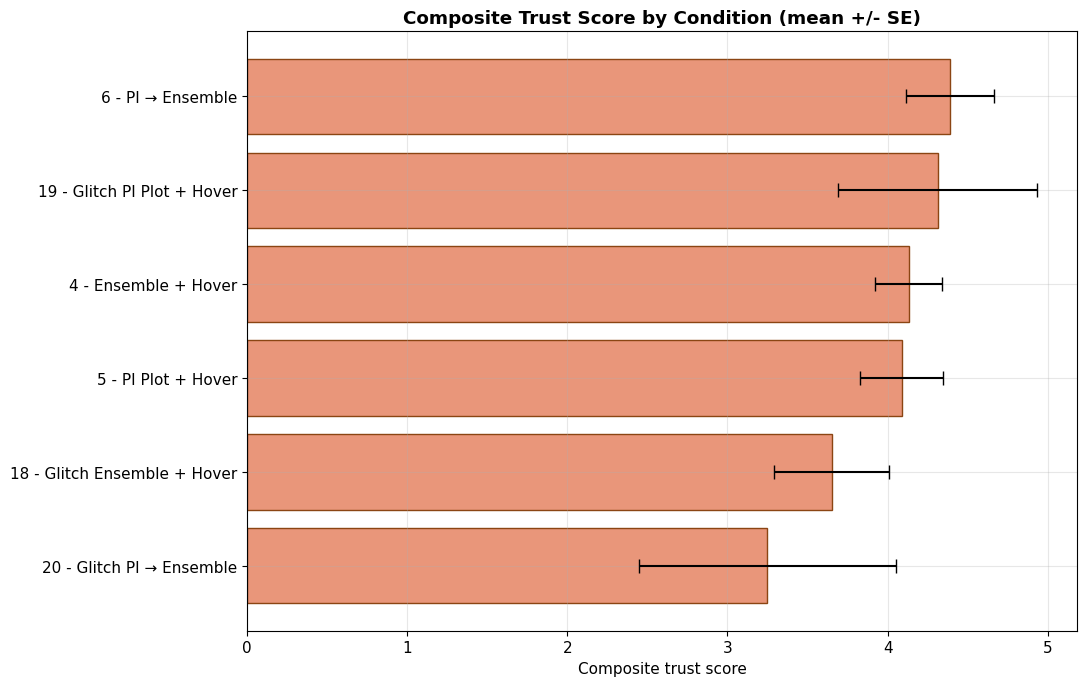

,condition_number,condition_name,mean_score,sd_score,n,se_score
0,6.0,PI → Ensemble,4.391,1.103,16,0.275750
1,19.0,Glitch PI Plot + Hover,4.312,1.248,4,0.624000
2,4.0,Ensemble + Hover,4.132,0.918,19,0.210604
3,5.0,PI Plot + Hover,4.088,1.064,17,0.258058
4,18.0,Glitch Ensemble + Hover,3.650,0.802,5,0.358665
5,20.0,Glitch PI → Ensemble,3.250,1.392,3,0.803672


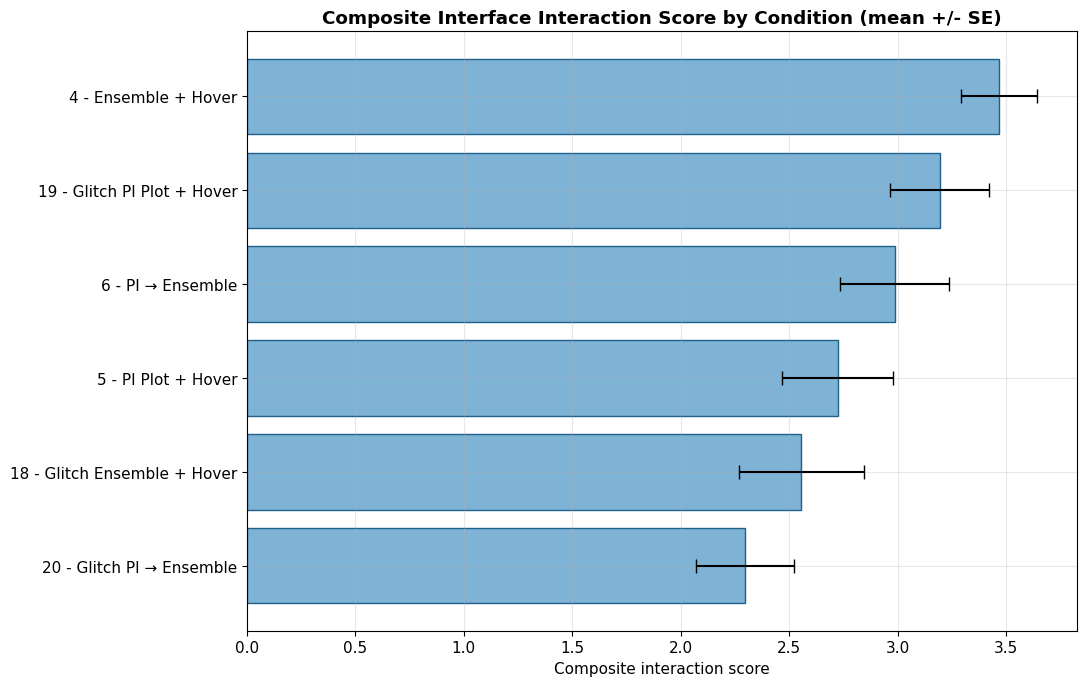

,condition_number,condition_name,mean_score,sd_score,n,se_score
0,4.0,Ensemble + Hover,3.468,0.772,19,0.177109
1,19.0,Glitch PI Plot + Hover,3.194,0.457,4,0.228500
2,6.0,PI → Ensemble,2.986,1.009,16,0.252250
3,5.0,PI Plot + Hover,2.725,1.056,17,0.256118
4,18.0,Glitch Ensemble + Hover,2.556,0.643,5,0.287558
5,20.0,Glitch PI → Ensemble,2.296,0.390,3,0.225167


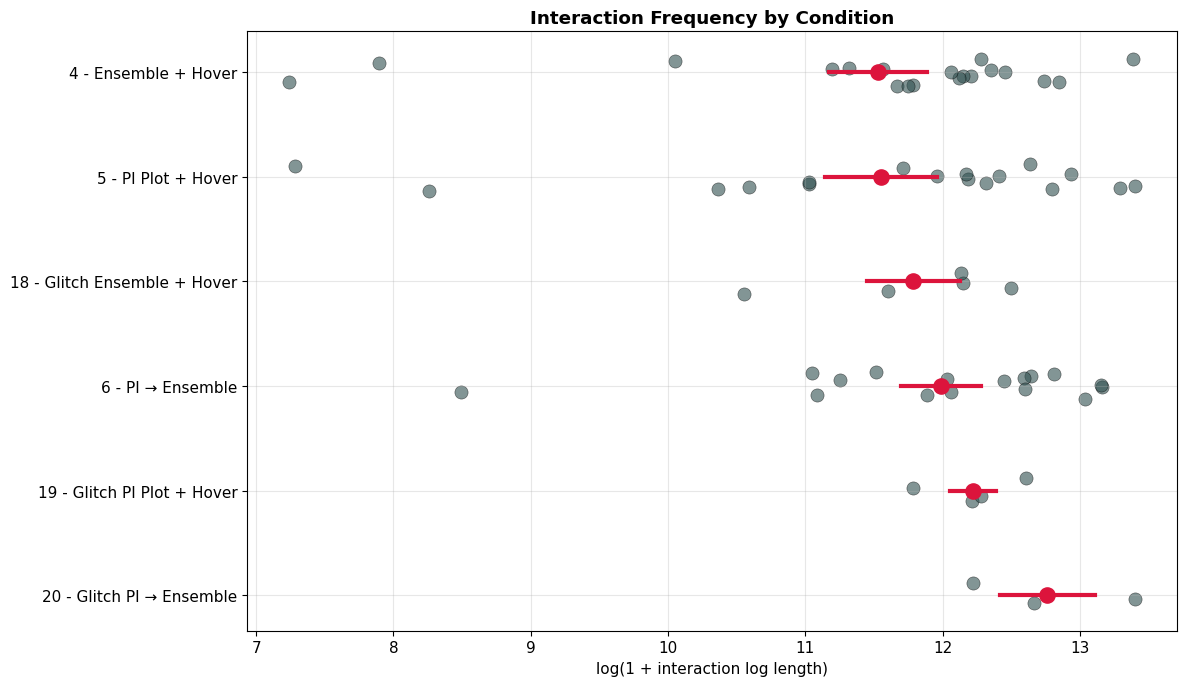

,condition_number,condition_name,mean_freq,sd_freq,n,se_freq
5,20.0,Glitch PI → Ensemble,12.763,0.594,3,0.342946
4,19.0,Glitch PI Plot + Hover,12.221,0.337,4,0.168500
2,6.0,PI → Ensemble,11.988,1.172,16,0.293000
3,18.0,Glitch Ensemble + Hover,11.787,0.759,5,0.339435
1,5.0,PI Plot + Hover,11.550,1.683,17,0.408187
0,4.0,Ensemble + Hover,11.529,1.568,19,0.359724


Feedback page rows: 64


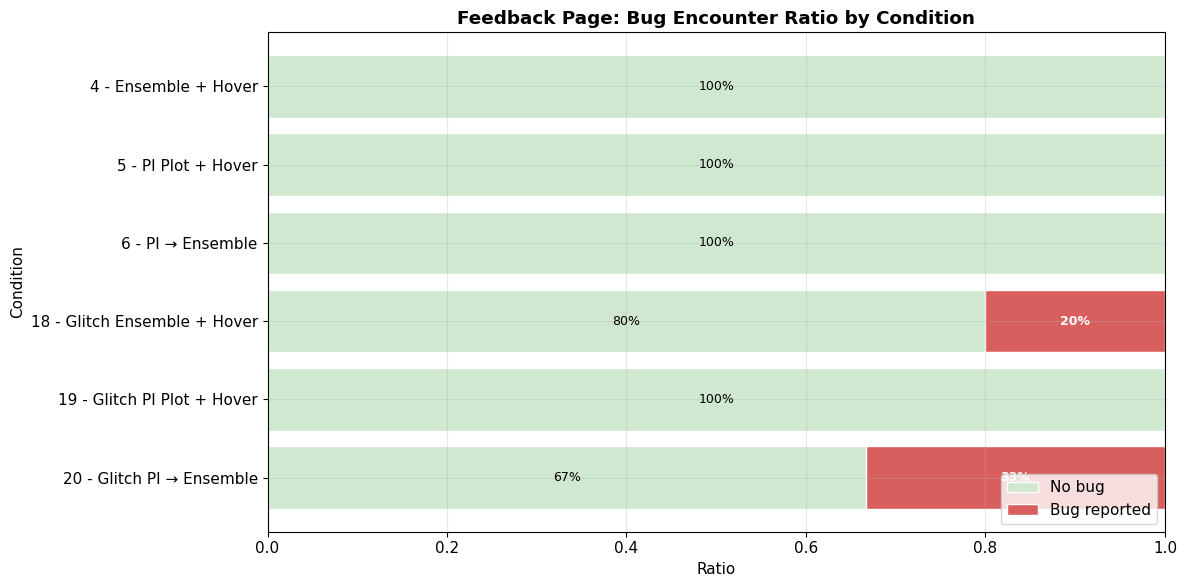

encounter_bug,condition_number,condition_name,No bug,Bug reported,No bug ratio,Bug reported ratio
0,4.0,Ensemble + Hover,19,0,1.000000,0.000000
1,5.0,PI Plot + Hover,17,0,1.000000,0.000000
2,6.0,PI → Ensemble,16,0,1.000000,0.000000
3,18.0,Glitch Ensemble + Hover,4,1,0.800000,0.200000
4,19.0,Glitch PI Plot + Hover,4,0,1.000000,0.000000
5,20.0,Glitch PI → Ensemble,2,1,0.666667,0.333333


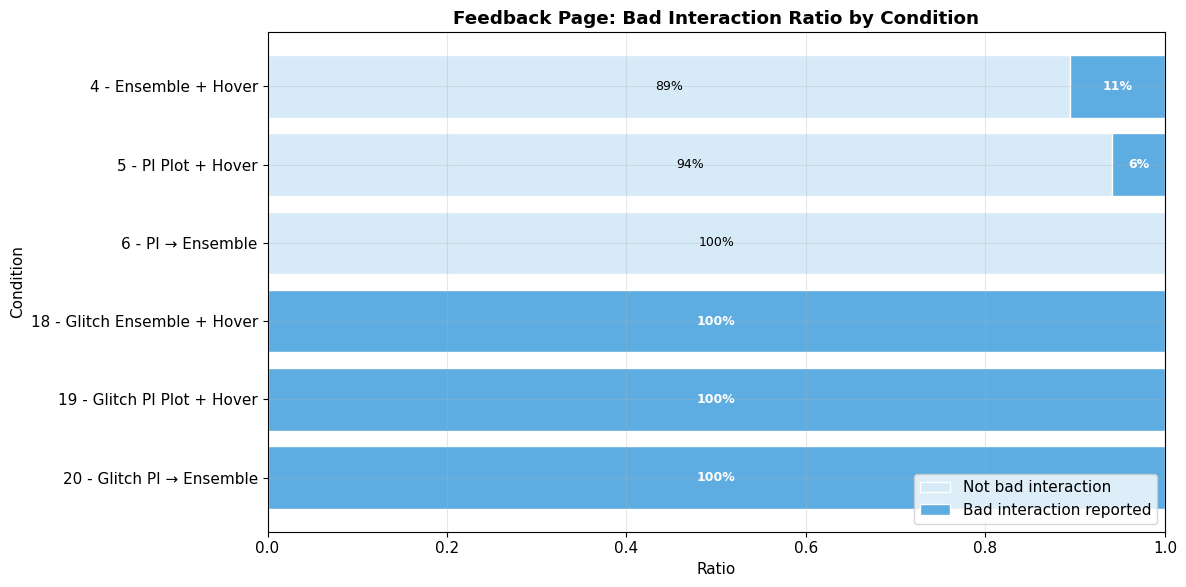

annoying_design,condition_number,condition_name,Not bad interaction,Bad interaction reported,Not bad interaction ratio,Bad interaction reported ratio
0,4.0,Ensemble + Hover,17,2,0.894737,0.105263
1,5.0,PI Plot + Hover,16,1,0.941176,0.058824
2,6.0,PI → Ensemble,16,0,1.000000,0.000000
3,18.0,Glitch Ensemble + Hover,0,5,0.000000,1.000000
4,19.0,Glitch PI Plot + Hover,0,4,0.000000,1.000000
5,20.0,Glitch PI → Ensemble,0,3,0.000000,1.000000


Feedback text box responses: bug elaboration


Feedback text box responses: bad interaction elaboration


In [9]:
import html
from IPython.display import HTML


def summarize_composite_scale(data, question_keys, score_column, reverse_columns=None):
    reverse_columns = set(reverse_columns or [])

    valid_data = data[data["condition_number"].notna()].copy()
    valid_data = valid_data[valid_data["condition_number"] != 0].copy()

    for col in question_keys:
        if col in reverse_columns:
            valid_data[f"{col}_scored"] = 6 - valid_data[col]
        else:
            valid_data[f"{col}_scored"] = valid_data[col]

    scored_columns = [f"{col}_scored" for col in question_keys]
    valid_data[score_column] = valid_data[scored_columns].mean(axis=1, skipna=True)

    summary = (
        valid_data.groupby(["condition_number", "condition_name"])
        .agg(
            mean_score=(score_column, "mean"),
            sd_score=(score_column, "std"),
            n=(score_column, "count"),
        )
        .round(3)
        .reset_index()
    )
    summary["se_score"] = summary["sd_score"] / np.sqrt(summary["n"])
    return valid_data, summary


def plot_condition_score_summary(summary, value_col, error_col, x_label, title, color, edgecolor):
    if summary.empty:
        print(f"No data available for {title}")
        return

    plot_summary = summary.sort_values(value_col, ascending=False).reset_index(drop=True)

    plt.figure(figsize=(11, 7))
    plt.barh(
        range(len(plot_summary)),
        plot_summary[value_col],
        xerr=plot_summary[error_col],
        color=color,
        edgecolor=edgecolor,
        capsize=5,
    )
    plt.yticks(
        range(len(plot_summary)),
        [
            f"{int(row.condition_number)} - {row.condition_name}"
            for row in plot_summary.itertuples(index=False)
        ],
    )
    plt.gca().invert_yaxis()
    plt.xlabel(x_label)
    plt.title(title, fontweight="bold")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def analyze_composite_trust_score(data):
    trust_columns = [
        "skeptical_rating",
        "data_trust",
        "usability_difficulty",
        "comprehension_ease",
    ]
    reverse_columns = ["skeptical_rating", "usability_difficulty"]

    valid_data, summary = summarize_composite_scale(
        data,
        trust_columns,
        score_column="composite_trust_score",
        reverse_columns=reverse_columns,
    )

    plot_condition_score_summary(
        summary,
        value_col="mean_score",
        error_col="se_score",
        x_label="Composite trust score",
        title="Composite Trust Score by Condition (mean +/- SE)",
        color="#E9967A",
        edgecolor="#8B4513",
    )

    display(summary.sort_values("mean_score", ascending=False).reset_index(drop=True))
    return valid_data, summary


def analyze_composite_interaction_score(data):
    valid_data, summary = summarize_composite_scale(
        data,
        INTERACTION_QUESTION_KEYS,
        score_column="composite_interaction_score",
    )

    plot_condition_score_summary(
        summary,
        value_col="mean_score",
        error_col="se_score",
        x_label="Composite interaction score",
        title="Composite Interface Interaction Score by Condition (mean +/- SE)",
        color="#7FB3D5",
        edgecolor="#1F618D",
    )

    display(summary.sort_values("mean_score", ascending=False).reset_index(drop=True))
    return valid_data, summary


def create_interaction_freq_dot_plot(data):
    valid_data = data[data["condition_number"].notna()].copy()
    valid_data = valid_data[valid_data["condition_number"] != 0].copy()

    summary = (
        valid_data.groupby(["condition_number", "condition_name"])
        .agg(
            mean_freq=("interaction_freq", "mean"),
            sd_freq=("interaction_freq", "std"),
            n=("interaction_freq", "count"),
        )
        .round(3)
        .reset_index()
        .sort_values("mean_freq", ascending=False)
    )
    summary["se_freq"] = summary["sd_freq"] / np.sqrt(summary["n"])

    label_order = [row.condition_name for row in summary.itertuples(index=False)]
    y_map = {label: index for index, label in enumerate(label_order)}

    plt.figure(figsize=(12, 7))
    np.random.seed(42)
    for _, row in valid_data.iterrows():
        y_pos = y_map[row["condition_name"]] + np.random.uniform(-0.14, 0.14)
        plt.scatter(
            row["interaction_freq"],
            y_pos,
            alpha=0.6,
            s=90,
            color="#2F4F4F",
            edgecolors="black",
            linewidth=0.4,
        )

    for _, row in summary.iterrows():
        y_pos = y_map[row["condition_name"]]
        plt.plot(
            [row["mean_freq"] - row["se_freq"], row["mean_freq"] + row["se_freq"]],
            [y_pos, y_pos],
            color="crimson",
            linewidth=3,
        )
        plt.scatter(row["mean_freq"], y_pos, color="crimson", s=120, zorder=3)

    plt.yticks(
        range(len(label_order)),
        [
            f"{int(row.condition_number)} - {row.condition_name}"
            for row in summary.itertuples(index=False)
        ],
    )
    plt.xlabel("log(1 + interaction log length)")
    plt.title("Interaction Frequency by Condition", fontweight="bold")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(summary)
    return summary


def normalize_yes_no(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in {"yes", "y", "true", "1"}:
        return "Yes"
    if text in {"no", "n", "false", "0"}:
        return "No"
    return np.nan


def prepare_feedback_page_data(data):
    feedback_rows = data[
        (data["trial_type"] == "interaction-feedback")
        & (data["phase"] == 2)
        & data["condition_number"].notna()
    ].copy()
    feedback_rows = feedback_rows[feedback_rows["condition_number"] != 0].copy()

    parsed_feedback = feedback_rows["response"].apply(parse_response_json).apply(pd.Series)
    feedback_rows = pd.concat(
        [feedback_rows.reset_index(drop=True), parsed_feedback.reset_index(drop=True)],
        axis=1,
    )

    for col in ["encounter_bug", "annoying_design"]:
        if col in feedback_rows.columns:
            feedback_rows[col] = feedback_rows[col].apply(normalize_yes_no)

    for col in ["bug_elaboration", "annoying_elaboration"]:
        if col in feedback_rows.columns:
            feedback_rows[col] = feedback_rows[col].fillna("").astype(str).str.strip()

    return feedback_rows.sort_values(["condition_number", "participant_id"]).reset_index(drop=True)


def create_feedback_ratio_stacked_bar(
    feedback_data,
    response_col,
    title,
    no_label,
    yes_label,
    no_color,
    yes_color,
):
    plot_rows = feedback_data[feedback_data[response_col].notna()].copy()
    if plot_rows.empty:
        print(f"No data available for {title}")
        return pd.DataFrame()

    summary = (
        plot_rows.groupby(["condition_number", "condition_name", response_col])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["No", "Yes"], fill_value=0)
        .reset_index()
        .sort_values("condition_number")
    )
    summary["total"] = summary["No"] + summary["Yes"]
    summary["no_ratio"] = np.where(summary["total"] > 0, summary["No"] / summary["total"], 0)
    summary["yes_ratio"] = np.where(summary["total"] > 0, summary["Yes"] / summary["total"], 0)

    y_pos = np.arange(len(summary))
    labels = [
        f"{int(row.condition_number)} - {row.condition_name}"
        for row in summary.itertuples(index=False)
    ]

    plt.figure(figsize=(12, 6))
    plt.barh(y_pos, summary["no_ratio"], color=no_color, edgecolor="white", label=no_label)
    plt.barh(
        y_pos,
        summary["yes_ratio"],
        left=summary["no_ratio"],
        color=yes_color,
        edgecolor="white",
        label=yes_label,
    )

    for idx, row in summary.iterrows():
        if row["no_ratio"] > 0.05:
            plt.text(
                row["no_ratio"] / 2,
                idx,
                f"{row['no_ratio']:.0%}",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
            )
        if row["yes_ratio"] > 0.05:
            plt.text(
                row["no_ratio"] + row["yes_ratio"] / 2,
                idx,
                f"{row['yes_ratio']:.0%}",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold",
            )

    plt.yticks(y_pos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Ratio")
    plt.ylabel("Condition")
    plt.title(title, fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(True, axis="x", alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    display(
        summary[
            [
                "condition_number",
                "condition_name",
                "No",
                "Yes",
                "no_ratio",
                "yes_ratio",
            ]
        ].rename(
            columns={
                "No": no_label,
                "Yes": yes_label,
                "no_ratio": f"{no_label} ratio",
                "yes_ratio": f"{yes_label} ratio",
            }
        )
    )
    return summary


def display_feedback_text_boxes(feedback_data, text_col, section_title):
    condition_rows = (
        feedback_data[["condition_number", "condition_name"]]
        .drop_duplicates()
        .sort_values("condition_number")
    )

    print(section_title)
    for row in condition_rows.itertuples(index=False):
        subset = feedback_data[
            (feedback_data["condition_number"] == row.condition_number)
            & feedback_data[text_col].ne("")
        ].copy()

        if subset.empty:
            content = "[no feedback submitted]"
        else:
            content = "\n".join(
                f"{participant_id}: {feedback}"
                for participant_id, feedback in subset[["participant_id", text_col]].itertuples(index=False)
            )

        box_html = f"""
        <div style=\"margin: 12px 0 20px 0;\">
            <div style=\"font-weight: 600; margin-bottom: 6px;\">{int(row.condition_number)} - {html.escape(str(row.condition_name))}</div>
            <div style=\"border: 1px solid #c9cdd3; border-radius: 8px; background: #f8f9fb; padding: 12px; white-space: pre-wrap; font-family: monospace; font-size: 12px; line-height: 1.5;\">{html.escape(content)}</div>
        </div>
        """
        display(HTML(box_html))


def analyze_feedback_page(data):
    feedback_data = prepare_feedback_page_data(data)
    print(f"Feedback page rows: {len(feedback_data)}")

    if feedback_data.empty:
        print("No feedback page rows found.")
        return feedback_data, pd.DataFrame(), pd.DataFrame()

    bug_ratio_summary = create_feedback_ratio_stacked_bar(
        feedback_data,
        response_col="encounter_bug",
        title="Feedback Page: Bug Encounter Ratio by Condition",
        no_label="No bug",
        yes_label="Bug reported",
        no_color="#CFE8CF",
        yes_color="#D95F5F",
    )

    bad_interaction_ratio_summary = create_feedback_ratio_stacked_bar(
        feedback_data,
        response_col="annoying_design",
        title="Feedback Page: Bad Interaction Ratio by Condition",
        no_label="Not bad interaction",
        yes_label="Bad interaction reported",
        no_color="#D6EAF8",
        yes_color="#5DADE2",
    )

    display_feedback_text_boxes(
        feedback_data,
        text_col="bug_elaboration",
        section_title="Feedback text box responses: bug elaboration",
    )
    display_feedback_text_boxes(
        feedback_data,
        text_col="annoying_elaboration",
        section_title="Feedback text box responses: bad interaction elaboration",
    )

    return feedback_data, bug_ratio_summary, bad_interaction_ratio_summary


composite_trust_data, composite_trust_summary = analyze_composite_trust_score(trust_data)
composite_interaction_data, composite_interaction_summary = analyze_composite_interaction_score(interaction_data)
interaction_freq_summary = create_interaction_freq_dot_plot(phase2_data)
feedback_page_data, feedback_bug_ratio_summary, feedback_bad_interaction_ratio_summary = analyze_feedback_page(combined_data)
